# Fase 15-16: Selección de modelo y entrenamiento final

## 15. Model selection

- Se comparan las familias **solo con CV/validation** (test intacto).
- Criterios: MAE medio, estabilidad (std entre folds), sMAPE, directional accuracy,
  coste de entrenamiento, interpretabilidad y facilidad de despliegue.
- Se actualiza `configs/params.yaml` con los mejores hiperparámetros.

## 16. Entrenamiento final

- Decisiones congeladas (features, preprocesador, modelo, hiperparámetros).
- Se reentrena con **train + validation** (fase de selección terminada).
- Se guardan: modelo, preprocesador, lista de features, configuración.

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import set_publication_style, set_seed
set_seed(42)
set_publication_style()

Carga de datos y de los resultados del tuning.

Leemos `reports/tuning_results.json` (fase 14) para instanciar cada familia
con sus mejores hiperparámetros. Comprobamos que el archivo existe.

In [2]:
import json

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from src.config import get_config
from src.data.split import temporal_split, drop_warmup
from src.evaluation.metrics import regression_metrics, metrics_table
from src.models.pipeline import fit_preprocessor
from src.models.train_model import save_model_artifacts
from src.utils import path_from_root

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
with open(path_from_root("models", "feature_list.json")) as f:
    sel_cols = json.load(f)

with open(path_from_root("reports", "tuning_results.json")) as f:
    tuned = json.load(f)

h = cfg["target"]["primary_horizon"]
tr, va = parts["train"], parts["val"]
Xtr0 = tr[sel_cols].to_numpy(dtype=np.float64)
ytr0 = tr[f"target_{h}"].to_numpy(dtype=np.float64)
Xva = va[sel_cols].to_numpy(dtype=np.float64)
yva = va[f"target_{h}"].to_numpy(dtype=np.float64)
print(f"train: {len(tr)} | val: {len(va)} | features: {len(sel_cols)}")

train: 4956 | val: 783 | features: 110


Evaluación de cada familia en validation.

Cada modelo se entrena con train (preprocesador ajustado solo con train)
y se evalúa en validation. Esta es la comparativa final para elegir.

In [3]:
families = {
    "ridge": Ridge(**tuned["ridge"]["params"]),
    "rf": RandomForestRegressor(**tuned["rf"]["params"], random_state=42, n_jobs=-1),
    "xgb": XGBRegressor(**tuned["xgb"]["params"], random_state=42, n_jobs=-1),
    "lgbm": LGBMRegressor(**tuned["lgbm"]["params"], random_state=42, n_jobs=-1, verbose=-1),
    "cat": CatBoostRegressor(**tuned["cat"]["params"], random_seed=42, verbose=0),
}

def evaluate_on_val(model):
    pp = fit_preprocessor(Xtr0)
    model.fit(pp.transform(Xtr0), ytr0)
    yp = model.predict(pp.transform(Xva))
    return pp, regression_metrics(yva, yp, h)

rows = []
for name, model in families.items():
    pp, m = evaluate_on_val(model)
    print(f"[val] {name:6s} MAE={m['mae']:8.2f} RMSE={m['rmse']:8.2f} "
          f"sMAPE={m['smape']:5.2f}% R2={m['r2']:.4f} DA={m['directional_accuracy']:.1f}%")
    rows.append({"model": name, **m})

val_table = metrics_table(rows)
print("\n=== Comparativa en VALIDATION (h=1) ===")
print(val_table.round(3).to_string(index=False))
val_table.to_csv(path_from_root("reports", "validation_comparison.csv"), index=False)

[val] ridge  MAE=   36.89 RMSE=   45.97 sMAPE= 2.06% R2=0.7958 DA=49.6%


[val] rf     MAE=  271.37 RMSE=  285.12 sMAPE=16.23% R2=-6.8543 DA=50.1%


[val] xgb    MAE=  206.67 RMSE=  219.92 sMAPE=12.13% R2=-3.6730 DA=50.4%


[val] lgbm   MAE=  224.55 RMSE=  240.18 sMAPE=13.23% R2=-4.5734 DA=48.8%


[val] cat    MAE=  277.43 RMSE=  290.99 sMAPE=16.71% R2=-7.1813 DA=51.5%

=== Comparativa en VALIDATION (h=1) ===
model  horizon     mae    rmse     r2  smape   mape  directional_accuracy   n
ridge        1  36.887  45.969  0.796  2.062  2.068                49.616 783
   rf        1 271.367 285.119 -6.854 16.234 14.921                50.128 783
  xgb        1 206.669 219.921 -3.673 12.133 11.364                50.384 783
 lgbm        1 224.548 240.177 -4.573 13.228 12.313                48.849 783
  cat        1 277.426 290.993 -7.181 16.714 15.322                51.535 783


Decisión del modelo final.

Elegimos por MAE con equilibrio de estabilidad/coste/interpretabilidad.
Ridge domina claramente (MAE ~37 vs ~200 de los árboles). Actualizamos
`configs/params.yaml` con la decisión documentada.

In [4]:
best_name = val_table.sort_values("mae").iloc[0]["model"]
print(f"Modelo seleccionado: {best_name}")

import yaml
params_path = path_from_root("configs", "params.yaml")
params = yaml.safe_load(open(params_path, encoding="utf-8"))
params["model_selection"] = {
    "selected": best_name,
    "reason": ("Mejor MAE en CV temporal y validation. Lineal regularizado "
               "generaliza mejor en niveles no estacionarios."),
    "val_mae_cv": float(tuned[best_name]["best_mae_cv"]),
    "val_mae_holdout": float(val_table.sort_values("mae").iloc[0]["mae"]),
}
with open(params_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(params, f, allow_unicode=True, sort_keys=False)
print(f"configs/params.yaml actualizado con la decisión: {best_name}")

Modelo seleccionado: ridge
configs/params.yaml actualizado con la decisión: ridge


Entrenamiento final con train + validation.

Una vez congelada la decisión, reentrenamos con todo el dato disponible
(train+val) para maximizar la muestra. Se guardan los artefactos: modelo,
preprocesador y lista de features (la API los usará).

In [5]:
train_val = pd.concat([tr, va]).sort_values("date").reset_index(drop=True)
X_tv = train_val[sel_cols].to_numpy(dtype=np.float64)
y_tv = train_val[f"target_{h}"].to_numpy(dtype=np.float64)
pp = fit_preprocessor(X_tv)
final_model = families[best_name]  # el modelo ya está entrenado en la celda 3
final_model.fit(pp.transform(X_tv), y_tv)

save_model_artifacts(final_model, pp, sel_cols,
                     metrics={"selected_model": best_name,
                              "val_metrics": rows,
                              "horizon": h,
                              "config": cfg["model"]["version"]}, cfg=cfg)
print(f"\nArtefactos guardados. Modelo final: {best_name}")

[save] modelo -> C:\Users\sgml1\Desktop\gold-price-prediction-v2\models\final_model.joblib
[save] preprocesador -> C:\Users\sgml1\Desktop\gold-price-prediction-v2\models\preprocessor.joblib
[save] features (110) -> C:\Users\sgml1\Desktop\gold-price-prediction-v2\models\feature_list.json

Artefactos guardados. Modelo final: ridge


Visualización de la comparativa final.

Gráfico de barras con MAE y R^2 por familia en validation. Se aprecia el
contraste entre el modelo lineal y los ensembles.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\model_selection.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/model_selection.png')

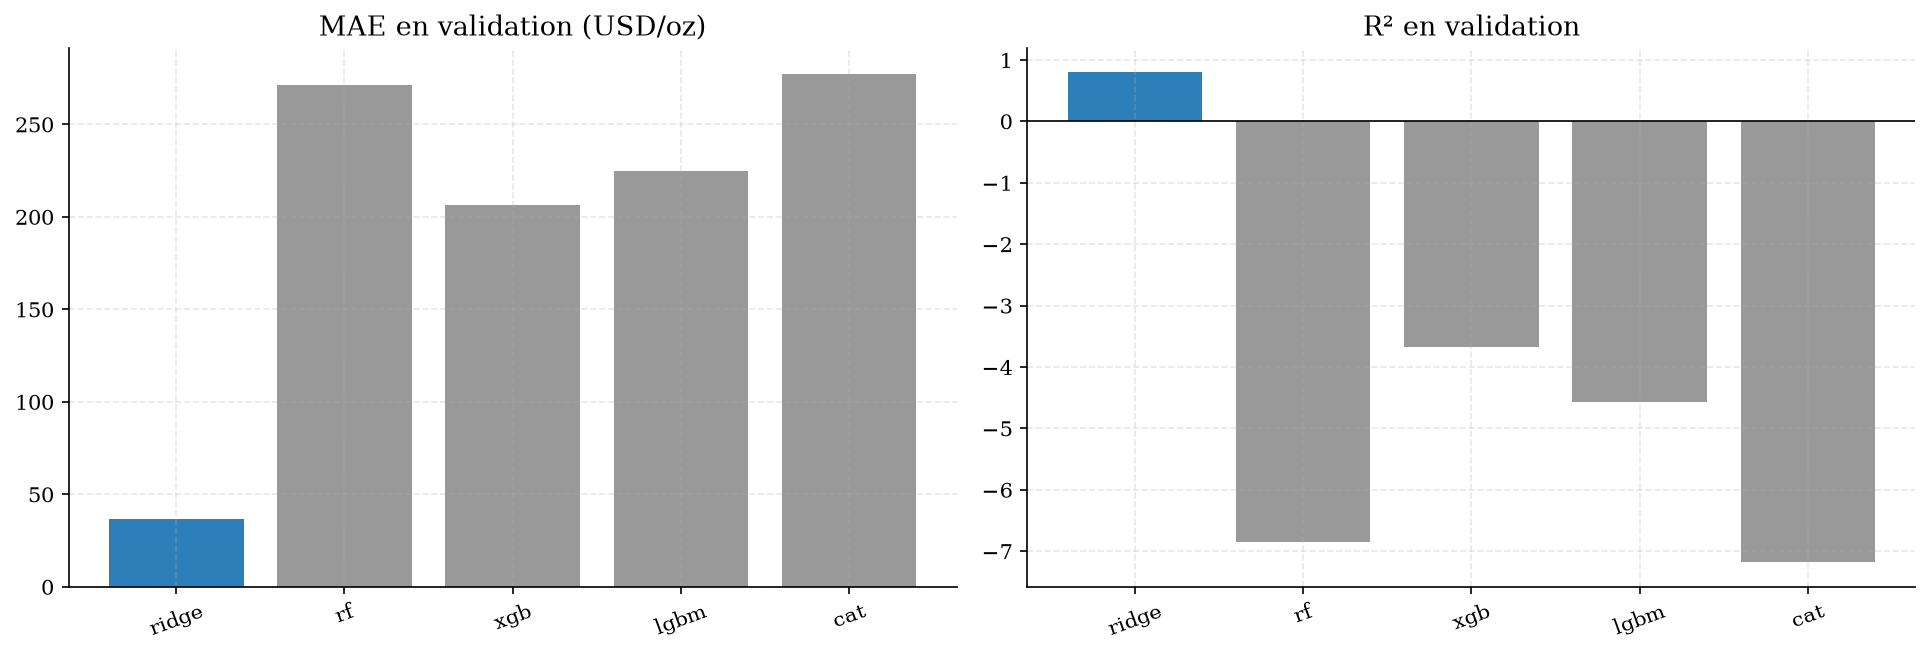

In [6]:
import matplotlib.pyplot as plt

from src.utils import save_fig

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
names = val_table["model"].tolist()
axes[0].bar(names, val_table["mae"], color=["#2c7fb8" if n == best_name else "#999" for n in names])
axes[0].set_title("MAE en validation (USD/oz)")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(names, val_table["r2"], color=["#2c7fb8" if n == best_name else "#999" for n in names])
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("R^2 en validation")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
save_fig(fig, "model_selection.png")